In [1]:
# ══════════════════════════════════════════════════════════════════════
# RECOMMENDED COMPUTE — explainability (SHAP + alert generation)
#   >>> cpu-8c-std   (8 cores, 64 GB RAM, ~RM4.49/hr)   <-- pick this (RF is CAPPED)
#   Why: TreeSHAP (RF/XGB) is CPU-only; the MLP DeepExplainer sample is tiny.
#        A GPU would not accelerate SHAP tree traversal.
#   If RF is max_depth=None: use cpu-16c-mem (256 GB) to hold the forest.
# ══════════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────
# SETUP — Portable project root (RUN THIS CELL FIRST)
#
# Sets the working directory to the ML-IDS project root so every relative
# path in this notebook resolves regardless of where Jupyter was launched.
# Override by exporting ML_IDS_ROOT=/path/to/ML-IDS before starting Jupyter.
# ──────────────────────────────────────────────────────────────────
import os
from pathlib import Path

def _find_project_root():
    for cand in (Path.cwd(), *Path.cwd().parents):
        if (cand / 'data').is_dir() and (cand / 'notebooks').is_dir():
            return cand
    return Path.cwd()

os.chdir(os.environ.get('ML_IDS_ROOT') or _find_project_root())
print('Project root:', os.getcwd())

Project root: /home/user/22056253/ML-IDS


In [2]:
# ─────────────────────────────────────────────────────────────────────
# CELL 0 — Setup: imports, data, feature names, shared utilities
# ─────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import shap
import glob
import os
import gc

MODELS  = 'models'
RESULTS = 'results'
os.makedirs(RESULTS, exist_ok=True)

X_test = np.load('data/features/X_test_hybrid.npy')
y_test = np.load('data/processed/y_test.npy')
le     = joblib.load(f'{MODELS}/label_encoder.pkl')

selected_indices = np.load(f'{MODELS}/selected_indices.npy')

# Reconstruct the 77-column preprocessed feature space so selected_indices
# maps to the correct names. Preprocessing drops 6 identifier columns
# (Flow ID, Src IP, Dst IP, Src Port, Dst Port, Timestamp) from the combined
# 84-column raw CSVs, leaving 77 feature columns. Reading a single raw CSV
# is wrong because Dst Port sits at column 0, shifting every index by 1.
_COLS_TO_DROP   = {'Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Timestamp', 'Label'}
# Prefer the canonical feature order saved by preprocessing.ipynb; fall back to
# reconstructing it from raw headers (deduped on stripped names so inconsistent
# header whitespace across files cannot silently misalign selected_indices).
import json as _json, os as _os
_canonical = 'models/feature_cols.json'
if _os.path.exists(_canonical):
    with open(_canonical) as _fh:
        _feature_cols = _json.load(_fh)
else:
    _raw_csvs = sorted(glob.glob('data/raw/*.csv'))
    if not _raw_csvs:
        raise FileNotFoundError(
            'Need models/feature_cols.json or data/raw/*.csv to resolve feature names.')
    _seen, _feature_cols = set(), []
    for _f in _raw_csvs:
        for _c in pd.read_csv(_f, nrows=0).columns:
            _cs = _c.strip()
            if _cs in _COLS_TO_DROP or _cs in _seen:
                continue
            _seen.add(_cs); _feature_cols.append(_cs)
handcrafted_names = [_feature_cols[i] for i in selected_indices]
latent_names      = [f"Latent_{i}" for i in range(16)]
feature_names     = handcrafted_names + latent_names

def predict_calibrated(proba, thresholds):
    """Pick the highest-prob class that exceeds its threshold; fallback to argmax."""
    masked     = np.where(proba >= thresholds, proba, -1.0)
    no_qualify = np.all(masked < 0, axis=1)
    result     = np.argmax(masked, axis=1)
    result[no_qualify] = np.argmax(proba[no_qualify], axis=1)
    return result

print(f"X_test shape:   {X_test.shape}")
print(f"Total features: {len(feature_names)}")
print(f"Classes:        {list(le.classes_)}")
print(f"Sample names:   {feature_names[:3]} ... {feature_names[40:43]}")

X_test shape:   (2434942, 56)
Total features: 56
Classes:        ['Benign', 'Bot', 'Brute Force -Web', 'Brute Force -XSS', 'DDOS attack-HOIC', 'DDOS attack-LOIC-UDP', 'DDoS attacks-LOIC-HTTP', 'DoS attacks-GoldenEye', 'DoS attacks-Hulk', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'Infilteration', 'SQL Injection', 'SSH-Bruteforce']
Sample names:   ['Init Fwd Win Byts', 'Fwd Pkts/s', 'Fwd Header Len'] ... ['Latent_0', 'Latent_1', 'Latent_2']


In [3]:
# ─────────────────────────────────────────────────────────────────────
# CELL 1 — Load MLP
#
# Rebuilds the exact MLP architecture used during training:
# 56 → 512 → 256 → 128 → 15 classes.
# weights_only=True prevents arbitrary code execution via pickle.
# ─────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),       nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.network(x)

mlp = MLP(X_test.shape[1], len(le.classes_))
mlp.load_state_dict(torch.load(f'{MODELS}/mlp.pth', weights_only=True))
mlp.eval()
print("MLP loaded successfully")

MLP loaded successfully


In [4]:
# ─────────────────────────────────────────────────────────────────────
# CELL 2 — Load RF, compute SHAP values, pre-compute alert predictions
#
# RF stays in memory through Cells 3, 6, and 7.
# XGBoost is computed in a subprocess (Cell 4): full XGBoost TreeSHAP over
# 45,000 internal trees would take hours regardless of hardware, so that
# stays a compute-bounded gain-importance job — not a memory workaround.
#
# SHAP settings (bounded for runtime, not memory):
#   - TreeExplainer uses the FULL 300-tree forest (exact TreeSHAP, no approx).
#   - N_PER_CLASS=40 → up to ~530 stratified rows (rare classes kept whole).
#     Exact TreeSHAP on this deep 300-tree forest is single-threaded and
#     costs ~seconds/sample, so the summary-plot sample size is the only
#     real runtime driver. 40/class keeps the mean-|SHAP| feature RANKING
#     statistically stable while cutting runtime ~4x vs 150/class. The
#     single-sample waterfall (Cell 6) and 5-sample alerts (Cell 7) are
#     unaffected by this — they explain fixed rows and stay fully exact.
# ─────────────────────────────────────────────────────────────────────
print("Loading Random Forest...")
rf = joblib.load(f'{MODELS}/random_forest.pkl')
print("RF loaded. Building SHAP explainer (full 300-tree forest)...")

# Stratified sample: up to 40 rows per class (~530 total; rare classes kept whole)
N_PER_CLASS = 40
rng = np.random.default_rng(42)
shap_indices = []
for cls in np.unique(y_test):
    cls_idx = np.where(y_test == cls)[0]
    n = min(len(cls_idx), N_PER_CLASS)
    shap_indices.extend(rng.choice(cls_idx, size=n, replace=False).tolist())
shap_indices  = np.array(shap_indices)
X_shap_sample = X_test[shap_indices]
y_shap_sample = y_test[shap_indices]
print(f"SHAP sample: {len(X_shap_sample)} rows across {len(np.unique(y_shap_sample))} classes")

rf_explainer   = shap.TreeExplainer(rf)
shap_values_rf = rf_explainer.shap_values(X_shap_sample, check_additivity=False)
print(f"SHAP values computed! Shape: {np.array(shap_values_rf).shape}")

# Pre-compute RF predictions while RF is loaded — avoids reloading later.
# Also saves alert_samples.npy that the XGB subprocess (Cell 4) will use.
thresholds_rf  = np.load(f'{MODELS}/thresholds_rf.npy')

# Curated alert samples — deliberately chosen (from the full-test calibrated
# predictions) to exercise EVERY branch of the alert engine in Cell 7, not
# just easy unanimous hits. Each index is a row of X_test:
#   0    unanimous attack (DDOS attack-HOIC)        -> HIGH,     AE corroborates
#   32   unanimous attack (Infilteration)           -> CRITICAL, AE corroborates
#   1841 RF says Benign, XGB+MLP say Infilteration  -> majority OVERRULES RF -> CRITICAL
#   27   only MLP flags (SQL Injection)             -> single vote -> LOW
#   1    all supervised Benign, AE flags anomaly    -> AE-only -> LOW / novel pattern
# The index list is saved so Cell 7 reads the exact same rows (no drift).
alert_indices  = np.array([0, 32, 1841, 27, 1])
alert_rf_proba = rf.predict_proba(X_test[alert_indices])
np.save(f'{RESULTS}/alert_indices.npy', alert_indices)
np.save(f'{RESULTS}/alert_samples.npy',  X_test[alert_indices])
np.save(f'{RESULTS}/alert_rf_proba.npy', alert_rf_proba)
print(f"RF alert probabilities pre-computed for {len(alert_indices)} samples.")

Loading Random Forest...
RF loaded. Building SHAP explainer (full 300-tree forest)...
SHAP sample: 567 rows across 15 classes
SHAP values computed! Shape: (567, 56, 15)
RF alert probabilities pre-computed for 5 samples.


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.1s finished


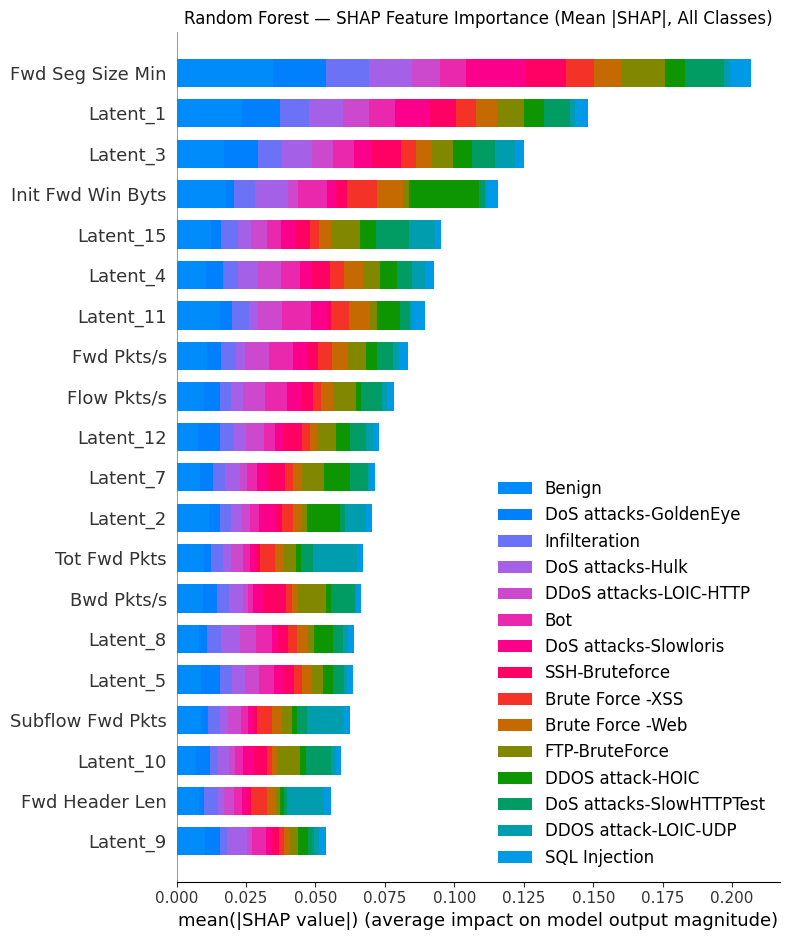

RF SHAP summary plot saved!


In [5]:
import matplotlib.pyplot as plt

# plot_type="bar" aggregates |SHAP| across all 15 classes into one readable chart.
# Without it, SHAP renders 15 tiny dot-plot panels that are illegible.
shap.summary_plot(
    shap_values_rf,
    X_shap_sample,
    feature_names=feature_names,
    class_names=list(le.classes_),
    max_display=20,
    plot_type="bar",
    show=False
)
plt.title("Random Forest — SHAP Feature Importance (Mean |SHAP|, All Classes)")
plt.tight_layout()
plt.savefig(f'{RESULTS}/shap_rf_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("RF SHAP summary plot saved!")

Computing XGBoost feature importances via subprocess...
Loading XGBoost...
XGBoost feature importances saved.
XGBoost alert probabilities saved.
Done — subprocess exiting, OS will reclaim XGBoost memory.



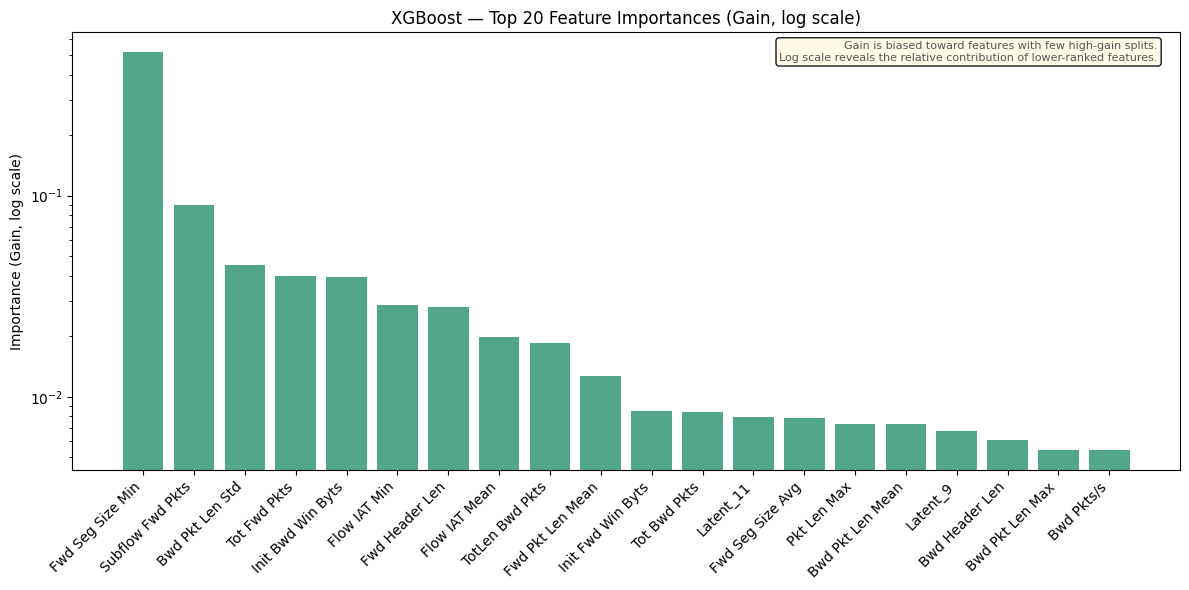

XGBoost feature importance plot saved!


In [6]:
import subprocess, sys, matplotlib.pyplot as plt

# XGBoost has 45,000 internal trees (3000 rounds × 15 classes) — full TreeSHAP
# would take hours. Run XGB in a subprocess instead: it loads XGB, computes
# gain-based feature importances and alert probabilities, saves them to disk,
# then exits. The OS guarantees full memory reclamation on subprocess exit,
# so RF (~11 GB) and XGB never compete for RAM in the same process.
print("Computing XGBoost feature importances via subprocess...")
result = subprocess.run(
    [sys.executable,
     'notebooks/compute_shap_xgb.py'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)
    raise RuntimeError('compute_shap_xgb.py failed — see STDERR above')

# XGBoost never enters the main process; load pre-computed importances from disk
importances_xgb = np.load(f'{RESULTS}/importances_xgb.npy')
top20_idx = np.argsort(importances_xgb)[::-1][:20]

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(range(20), importances_xgb[top20_idx], color='#52A788')
ax.set_yscale('log')
ax.set_xticks(range(20))
ax.set_xticklabels([feature_names[i] for i in top20_idx], rotation=45, ha='right')
ax.set_title('XGBoost — Top 20 Feature Importances (Gain, log scale)')
ax.set_ylabel('Importance (Gain, log scale)')
ax.text(0.98, 0.98,
        'Gain is biased toward features with few high-gain splits.\n'
        'Log scale reveals the relative contribution of lower-ranked features.',
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='#555',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#fffbe6', alpha=0.9))
plt.tight_layout()
plt.savefig(f'{RESULTS}/shap_xgb_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("XGBoost feature importance plot saved!")

Computing SHAP values for MLP...
This may take a few minutes...


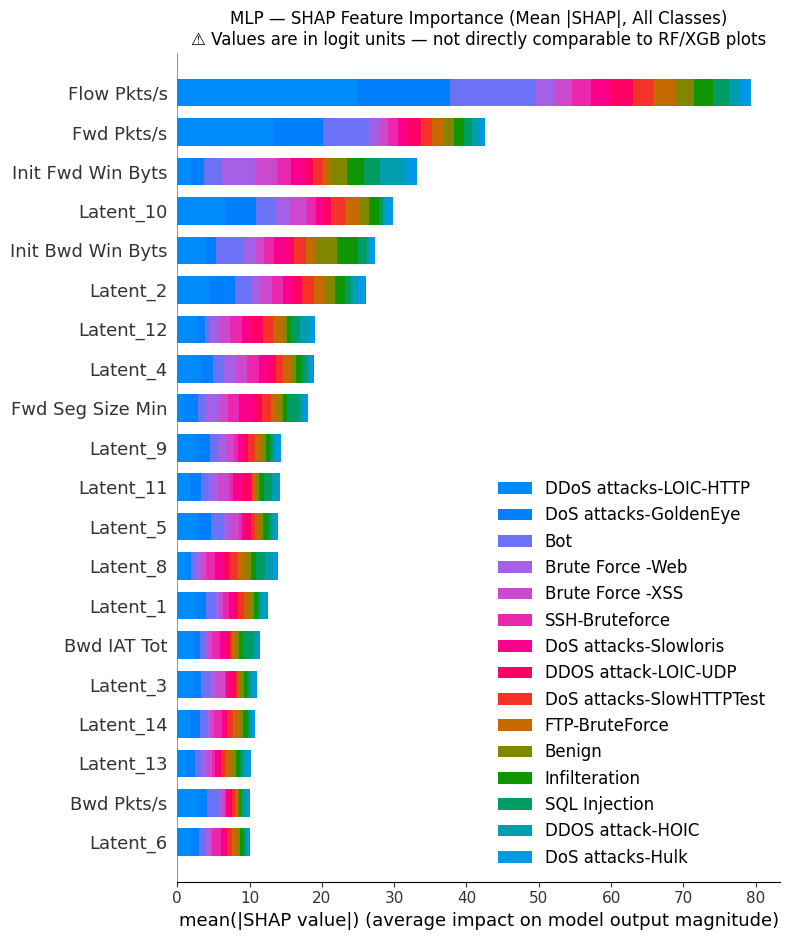

MLP SHAP plot saved!


In [7]:
import matplotlib.pyplot as plt

print("Computing SHAP values for MLP...")
print("This may take a few minutes...")

# Background: first 100 rows represent the real input distribution (~83% Benign)
background_tensor = torch.FloatTensor(X_test[:100])
mlp_explainer     = shap.DeepExplainer(mlp, background_tensor)

# Use the same stratified sample as RF for a consistent comparison
X_mlp_sample    = torch.FloatTensor(X_shap_sample)
shap_values_mlp = mlp_explainer.shap_values(X_mlp_sample)

# NOTE: DeepExplainer computes SHAP against raw logit outputs (pre-softmax),
# so the x-axis is in logit units (0–80 range here). TreeExplainer for RF/XGB
# computes SHAP against predict_proba (post-softmax, 0–1 range). The feature
# rankings are comparable across models but the numeric values are NOT.
shap.summary_plot(
    shap_values_mlp,
    X_shap_sample,
    feature_names=feature_names,
    class_names=list(le.classes_),
    max_display=20,
    plot_type="bar",
    show=False
)
plt.title("MLP — SHAP Feature Importance (Mean |SHAP|, All Classes)\n"
          "⚠ Values are in logit units — not directly comparable to RF/XGB plots")
plt.tight_layout()
plt.savefig(f'{RESULTS}/shap_mlp_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("MLP SHAP plot saved!")

Sample index: 0
Actual class: DDOS attack-HOIC
RF predicted: DDOS attack-HOIC


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 300 out of 300 | elapsed:    0.0s finished


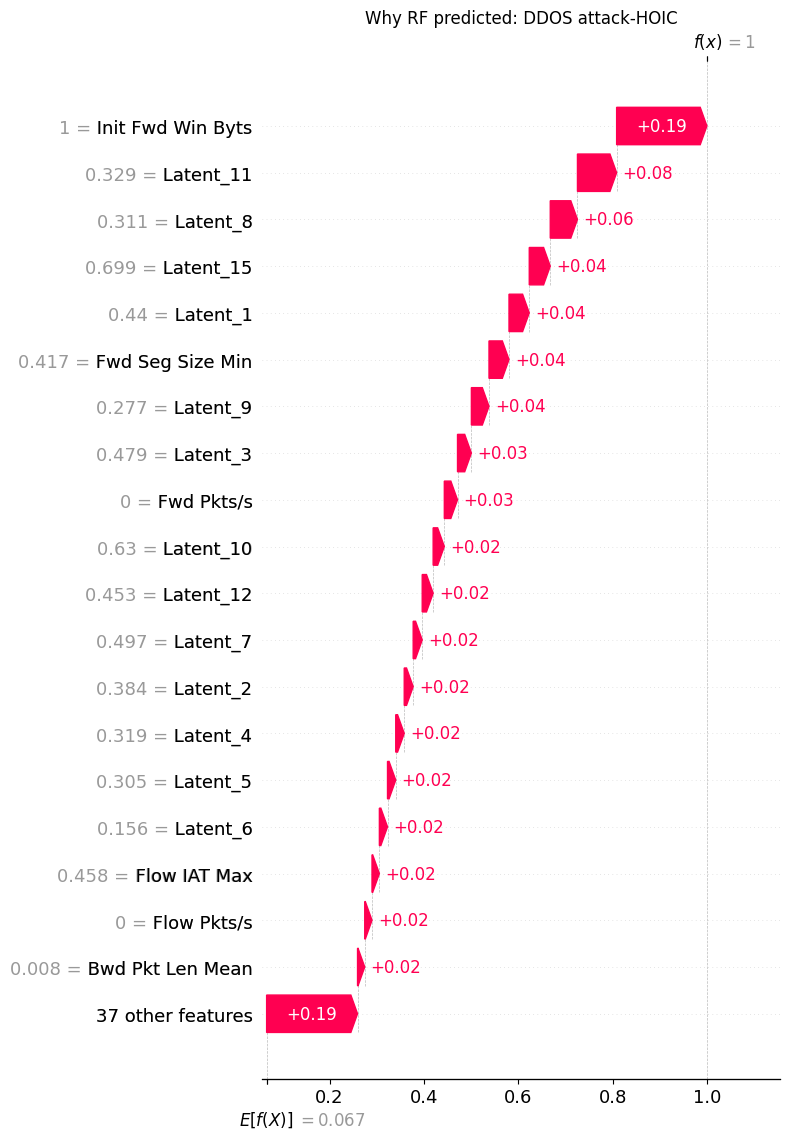

In [8]:
import matplotlib.pyplot as plt

# RF is still in memory from Cell 2 — no reload needed.
attack_indices = np.where(y_test != 0)[0]
sample_idx     = attack_indices[0]
sample         = X_test[sample_idx:sample_idx + 1]

rf_proba = rf.predict_proba(sample)
rf_pred  = int(predict_calibrated(rf_proba, thresholds_rf)[0])
actual   = y_test[sample_idx]

print(f"Sample index: {sample_idx}")
print(f"Actual class: {le.classes_[actual]}")
print(f"RF predicted: {le.classes_[rf_pred]}")

# shap_values returns (n_samples, n_features, n_classes) — index as [0, :, class]
shap_single = rf_explainer.shap_values(sample, check_additivity=False)

# max_display=20 prevents "N other features" from collapsing too many contributions
shap.waterfall_plot(
    shap.Explanation(
        values=shap_single[0, :, rf_pred],
        base_values=rf_explainer.expected_value[rf_pred],
        data=sample[0],
        feature_names=feature_names
    ),
    max_display=20,
    show=False
)
plt.title(f"Why RF predicted: {le.classes_[rf_pred]}")
plt.tight_layout()
plt.savefig(f'{RESULTS}/shap_waterfall_sample.png', bbox_inches='tight', dpi=150)
plt.show()

In [9]:
# ─────────────────────────────────────────────────────────────────────
# CELL 7 — Alert generation with calibrated predictions and AE detector
#
# RF probabilities:  pre-computed in Cell 2  → alert_rf_proba.npy
# XGB probabilities: pre-computed in Cell 4 subprocess → alert_xgb_proba.npy
# Alert row indices: chosen in Cell 2         → alert_indices.npy
# All are loaded from disk — no large model reload needed here.
#
# The 5 curated flows deliberately span every decision path:
#   unanimous HIGH, unanimous CRITICAL, RF-overruled-by-majority,
#   single-model vote (LOW), and AE-only anomaly (LOW / novel).
# ─────────────────────────────────────────────────────────────────────
import json
from collections import Counter
from datetime import datetime, timezone

# ── AE anomaly detector ─────────────────────────────────────────────
class AEAnomaly(nn.Module):
    def __init__(self, input_dim=56):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim, 32), nn.ReLU(),
                                     nn.Linear(32, 16),        nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(16, 32),        nn.ReLU(),
                                     nn.Linear(32, input_dim), nn.Sigmoid())
    def forward(self, x):
        return self.decoder(self.encoder(x))

ae_model = AEAnomaly(input_dim=56)
ae_model.load_state_dict(torch.load(f'{MODELS}/autoencoder_anomaly.pth',
                                    weights_only=True, map_location='cpu'))
ae_model.eval()
ae_threshold = float(np.load(f'{MODELS}/threshold_ae_anomaly.npy')[0])

# ── Calibrated thresholds ───────────────────────────────────────────
thresholds_rf  = np.load(f'{MODELS}/thresholds_rf.npy')   # loaded here in case
thresholds_xgb = np.load(f'{MODELS}/thresholds_xgb.npy')  # Cell 2 was not run
thresholds_mlp = np.load(f'{MODELS}/thresholds_mlp.npy')

# ── Severity lookup ─────────────────────────────────────────────────
_SEVERITY = {
    'SQL Injection':          'CRITICAL',
    'Infilteration':          'CRITICAL',
    'Brute Force -Web':       'CRITICAL',
    'Bot':                    'HIGH',
    'DDOS attack-HOIC':       'HIGH',
    'DDoS attacks-LOIC-HTTP': 'HIGH',
}

def generate_alert(flow_features, flow_id, rf_proba, xgb_proba, mlp_model,
                   ae_detector, ae_thresh,
                   thr_rf, thr_xgb, thr_mlp,
                   rf_explainer, le, feature_names):

    sample = flow_features.reshape(1, -1)

    # ── Calibrated predictions (RF + XGB use pre-computed probas) ──
    rf_pred  = int(predict_calibrated(rf_proba,  thr_rf)[0])
    xgb_pred = int(predict_calibrated(xgb_proba, thr_xgb)[0])

    mlp_model.eval()
    with torch.no_grad():
        logits    = mlp_model(torch.FloatTensor(sample))
        mlp_proba = torch.softmax(logits, dim=1).numpy()
    mlp_pred = int(predict_calibrated(mlp_proba, thr_mlp)[0])

    rf_conf  = float(rf_proba[0,  rf_pred])
    mlp_conf = float(mlp_proba[0, mlp_pred])

    # ── AE anomaly detection ────────────────────────────────────────
    with torch.no_grad():
        x_t    = torch.FloatTensor(sample)
        recon  = ae_detector(x_t)
        ae_mse = float(((x_t - recon) ** 2).mean().item())
    ae_flag = ae_mse > ae_thresh

    # ── Severity: require consensus from ≥2 supervised models ───────
    preds = {
        'rf':  le.classes_[rf_pred],
        'xgb': le.classes_[xgb_pred],
        'mlp': le.classes_[mlp_pred],
    }
    attack_preds = {m: c for m, c in preds.items() if c != 'Benign'}
    n_attack     = len(attack_preds)

    if not attack_preds and not ae_flag:
        severity  = 'NONE'
        consensus = 'Benign'
    elif not attack_preds and ae_flag:
        severity  = 'LOW'
        consensus = 'Unknown (AE anomaly only)'
    elif n_attack == 1:
        severity  = 'LOW'
        consensus = next(iter(attack_preds.values()))
    else:
        # ≥2 models flag an attack: consensus is the actual MAJORITY class
        # among the attack votes (not just RF's opinion). Ties broken in
        # favour of RF's prediction when RF is among the tied leaders.
        vote_counts = Counter(attack_preds.values())
        top_count   = max(vote_counts.values())
        leaders     = [c for c, n in vote_counts.items() if n == top_count]
        consensus   = preds['rf'] if preds['rf'] in leaders else leaders[0]
        severity    = _SEVERITY.get(consensus, 'MEDIUM')

    # ── AE corroboration note (accurate to how many models agreed) ──
    if attack_preds and consensus != 'Benign':
        if ae_flag:
            ae_note = "AE corroborates supervised detection"
        elif n_attack >= 2:
            ae_note = ("AE did not flag anomaly — this attack type mimics benign "
                       "traffic patterns; multiple supervised models still agree")
        else:
            ae_note = ("AE did not flag anomaly and only one supervised model "
                       "raised this — treat as low-confidence / possible false positive")
    elif ae_flag and not attack_preds:
        ae_note = ("AE flagged an anomaly with no supervised agreement — "
                   "possible novel/unknown pattern; review manually")
    else:
        ae_note = ""

    # ── SHAP top-5 features driving the flagged class ───────────────
    # Explain the CONSENSUS class when it is a concrete label (so a flow the
    # ensemble escalates isn't explained by RF's rejected Benign call); fall
    # back to RF's own prediction for Benign / 'Unknown (AE anomaly only)'.
    # shap_values returns (n_samples, n_features, n_classes) — index [0, :, class].
    class_lookup = {c: i for i, c in enumerate(le.classes_)}
    explain_cls  = class_lookup.get(consensus, rf_pred)
    shap_vals    = rf_explainer.shap_values(sample, check_additivity=False)
    class_shap   = shap_vals[0, :, explain_cls]
    top5_idx     = np.argsort(np.abs(class_shap))[::-1][:5]
    top5_features = [
        {"feature": feature_names[i], "shap_value": round(float(class_shap[i]), 4)}
        for i in top5_idx
    ]

    return {
        "alert_id":          f"ALERT-{flow_id:05d}",
        "timestamp":         datetime.now(timezone.utc).isoformat(),
        "flow_id":           flow_id,
        "rf_prediction":     preds['rf'],
        "xgb_prediction":    preds['xgb'],
        "mlp_prediction":    preds['mlp'],
        "rf_confidence":     round(rf_conf,  4),
        "mlp_confidence":    round(mlp_conf, 4),
        "ae_recon_error":    round(ae_mse,   6),
        "ae_anomaly_flag":   bool(ae_flag),
        "ae_note":           ae_note,
        "severity":          severity,
        "consensus_class":   consensus,
        "shap_explains":     le.classes_[explain_cls],
        "top_shap_features": top5_features,
    }

# ── Load pre-computed probabilities and the curated row indices ─────
alert_rf_proba  = np.load(f'{RESULTS}/alert_rf_proba.npy')
alert_xgb_proba = np.load(f'{RESULTS}/alert_xgb_proba.npy')
alert_indices   = np.load(f'{RESULTS}/alert_indices.npy')

alerts = []
print("Generating alerts...\n")
for i, idx in enumerate(alert_indices):
    idx = int(idx)
    alert = generate_alert(
        X_test[idx], idx,
        alert_rf_proba[i:i+1], alert_xgb_proba[i:i+1], mlp,
        ae_model, ae_threshold,
        thresholds_rf, thresholds_xgb, thresholds_mlp,
        rf_explainer, le, feature_names
    )
    alerts.append(alert)
    print(f"Alert {i + 1}  (flow #{idx}):")
    print(f"  Actual:      {le.classes_[y_test[idx]]}")
    print(f"  RF:          {alert['rf_prediction']}  (conf: {alert['rf_confidence']})")
    print(f"  XGB:         {alert['xgb_prediction']}")
    print(f"  MLP:         {alert['mlp_prediction']}")
    print(f"  AE anomaly:  {alert['ae_anomaly_flag']}  (error: {alert['ae_recon_error']})")
    print(f"  AE note:     {alert['ae_note']}")
    print(f"  Severity:    {alert['severity']}")
    print(f"  Consensus:   {alert['consensus_class']}")
    print(f"  SHAP for:    {alert['shap_explains']}  → "
          f"{alert['top_shap_features'][0]['feature']} = "
          f"{alert['top_shap_features'][0]['shap_value']}")
    print()

with open(f'{RESULTS}/sample_alerts.json', 'w') as f:
    json.dump(alerts, f, indent=2)
print("Alerts saved to sample_alerts.json!")

Generating alerts...

Alert 1  (flow #0):
  Actual:      DDOS attack-HOIC
  RF:          DDOS attack-HOIC  (conf: 1.0)
  XGB:         DDOS attack-HOIC
  MLP:         DDOS attack-HOIC
  AE anomaly:  True  (error: 0.000652)
  AE note:     AE corroborates supervised detection
  Severity:    HIGH
  Consensus:   DDOS attack-HOIC
  SHAP for:    DDOS attack-HOIC  → Init Fwd Win Byts = 0.1914

Alert 2  (flow #32):
  Actual:      Infilteration
  RF:          Infilteration  (conf: 0.9997)
  XGB:         Infilteration
  MLP:         Infilteration
  AE anomaly:  True  (error: 0.000117)
  AE note:     AE corroborates supervised detection
  Severity:    CRITICAL
  Consensus:   Infilteration
  SHAP for:    Infilteration  → Latent_12 = 0.0636

Alert 3  (flow #1841):
  Actual:      Infilteration
  RF:          Benign  (conf: 0.1348)
  XGB:         Infilteration
  MLP:         Infilteration
  AE anomaly:  True  (error: 0.000181)
  AE note:     AE corroborates supervised detection
  Severity:    CRITICAL

In [10]:
print("=" * 50)
print("EXPLAINABILITY COMPLETE — FILES SAVED:")
print("=" * 50)

results_files = [
    'shap_rf_summary.png',
    'shap_xgb_summary.png',
    'shap_mlp_summary.png',
    'shap_waterfall_sample.png',
    'sample_alerts.json',
]

for fname in results_files:
    path = f'{RESULTS}/{fname}'
    if os.path.exists(path):
        size = os.path.getsize(path) / 1024
        print(f"  OK  {fname}: {size:.1f} KB")
    else:
        print(f"  MISSING  {fname}")

EXPLAINABILITY COMPLETE — FILES SAVED:
  OK  shap_rf_summary.png: 163.9 KB
  OK  shap_xgb_summary.png: 124.9 KB
  OK  shap_mlp_summary.png: 169.3 KB
  OK  shap_waterfall_sample.png: 173.7 KB
  OK  sample_alerts.json: 4.7 KB
